In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix , accuracy_score ,classification_report
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense # fully connected layers (every neuron connects to every neuron in the nxt layer)
from tensorflow.keras.layers import Dropout # Randomly drops some neurons during training to prevent overfitting
from tensorflow.keras.utils  import to_categorical # converts class lables (like 0,1,2) into one-hot encoded format like [1,0,0], [0,1,0]

In [24]:
df = sn.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [26]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [27]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


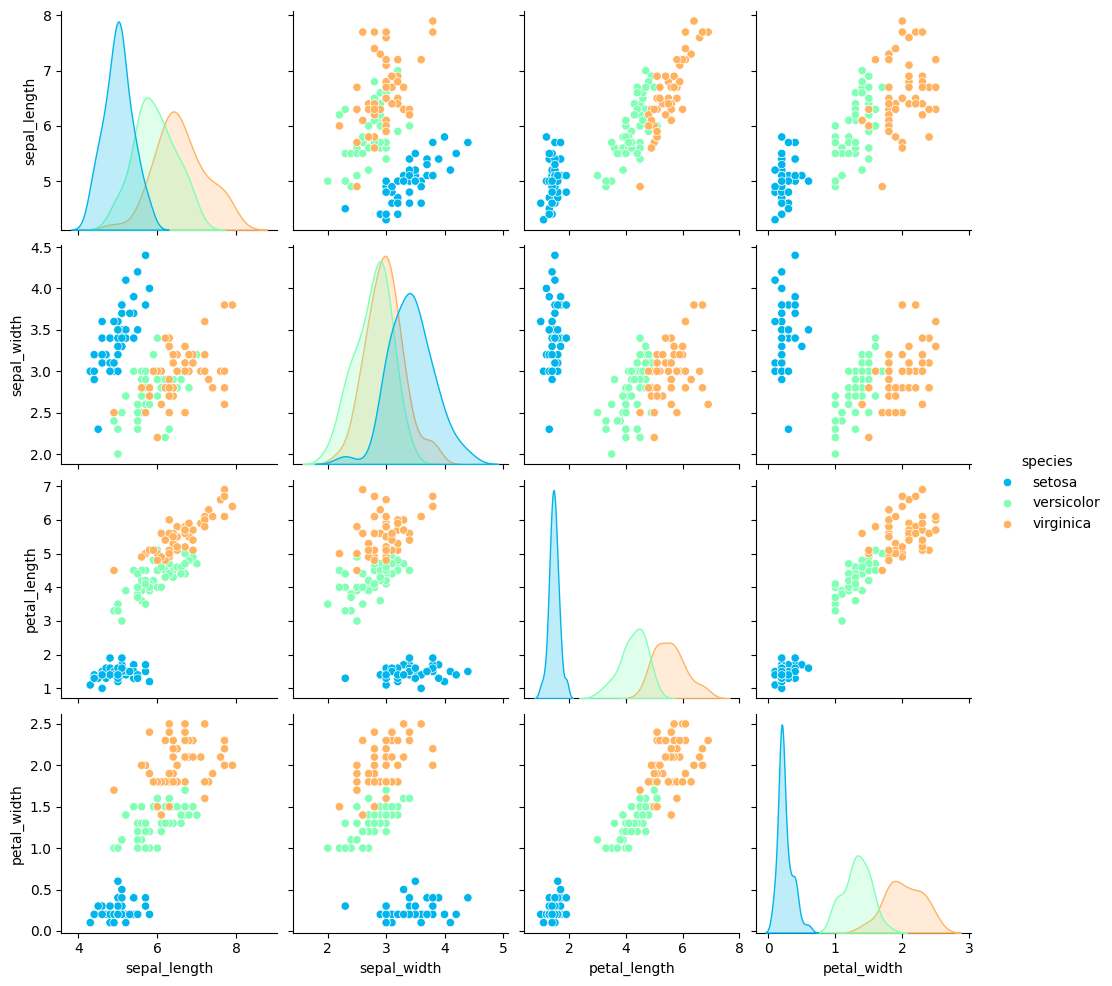

In [28]:
sn.pairplot(df, palette='rainbow', hue = 'species')

In [29]:
X = df.drop(['species'], axis=1)
y = df['species']

In [30]:
le  = LabelEncoder()
y_int = le.fit_transform(y)
print(y_int)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y_int, test_size=0.2, random_state=42, stratify=y_int)

In [32]:
scaler = StandardScaler()
X_train_sl = scaler.fit_transform(X_train)
X_test_sl = scaler.fit_transform(X_test)

In [33]:
per = Perceptron(max_iter = 1000, random_state=42)
per.fit(X_train_sl, y_train)

Perceptron(random_state=42)

In [34]:
y_pred_per = per.predict(X_test_sl)
print(y_pred_per)

[0 2 1 1 0 2 0 0 2 1 2 2 2 2 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [35]:
accuracy = accuracy_score(y_test, y_pred_per)
print(accuracy)

print(classification_report(y_test, y_pred_per))

0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.70      0.82        10
           2       0.77      1.00      0.87        10

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



In [36]:
y_train_cols  = to_categorical(y_train, num_classes = 3 )
y_test_cols  = to_categorical(y_test, num_classes = 3 )
print(y_train_cols)
print(y_test_cols)

[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1.

In [37]:
model = Sequential([
    Dense(16,input_dim = 4, activation = 'relu'),
    Dense(8, activation = 'relu'),
    Dense(3, activation = 'softmax')
])


In [38]:
model.compile(optimizer='adam' ,loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [39]:
history = model.fit(X_train_sl, y_train_cols, epochs=100 , batch_size = 8, validation_split=0.2, verbose = 1)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4896 - loss: 1.0039 - val_accuracy: 0.5833 - val_loss: 1.0261
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5729 - loss: 0.9558 - val_accuracy: 0.5833 - val_loss: 0.9855
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6146 - loss: 0.9092 - val_accuracy: 0.5833 - val_loss: 0.9453
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6250 - loss: 0.8631 - val_accuracy: 0.5833 - val_loss: 0.9036
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6667 - loss: 0.8188 - val_accuracy: 0.5833 - val_loss: 0.8620
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6771 - loss: 0.7732 - val_accuracy: 0.5833 - val_loss: 0.8219
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6771 - loss: 0.7294 - val_accuracy: 0.5833 - val_loss: 0.7855
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6875 - loss: 0.6909 - val_accuracy: 0.5833 - 

In [40]:
loss , accuracy = model.evaluate(X_test_sl , y_test_cols, verbose = 0)
print(accuracy)

0.9666666388511658


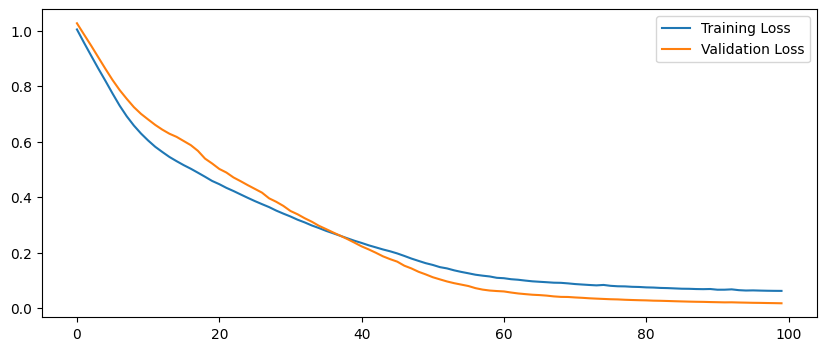

In [41]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend()
plt.show()

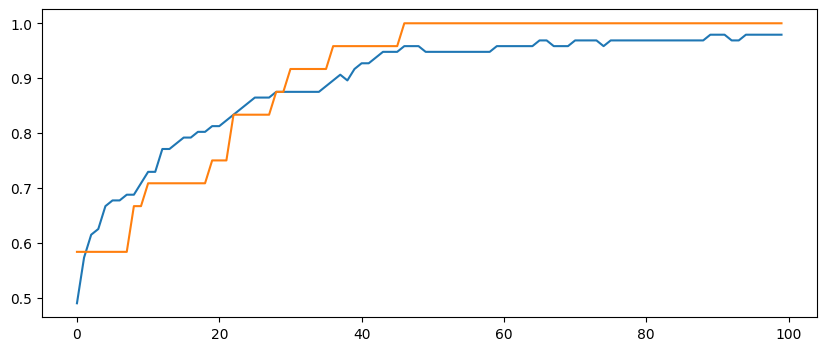

In [42]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')

In [43]:
import joblib

# Save the Perceptron model
joblib.dump(per, 'perceptron_model.joblib')
print('Perceptron model saved as perceptron_model.joblib')

# Save the Keras model (TensorFlow models have their own saving mechanism, but for general Python objects, joblib works too if you want to save the entire Keras model object)
# Note: For Keras models, it's generally recommended to use model.save() or model.save_weights() for better portability and future compatibility.
# However, to demonstrate joblib as requested, we'll save the model object directly.
joblib.dump(model, 'keras_model.joblib')
print('Keras model saved as keras_model.joblib')

Perceptron model saved as perceptron_model.joblib
Keras model saved as keras_model.joblib


Now, let's load the saved models to verify they can be re-used.

In [44]:
# Load the Perceptron model
loaded_per_model = joblib.load('perceptron_model.joblib')
print('Perceptron model loaded successfully:')
print(loaded_per_model)

# Make predictions with the loaded Perceptron model
loaded_y_pred_per = loaded_per_model.predict(X_test_sl)
print('\nPredictions with loaded Perceptron model (first 5):')
print(loaded_y_pred_per[:5])

# Load the Keras model
loaded_keras_model = joblib.load('keras_model.joblib')
print('\nKeras model loaded successfully:')
loaded_keras_model.summary()

# Make predictions with the loaded Keras model
loaded_y_pred_keras_probs = loaded_keras_model.predict(X_test_sl)
loaded_y_pred_keras = np.argmax(loaded_y_pred_keras_probs, axis=1)
print('\nPredictions with loaded Keras model (first 5):')
print(loaded_y_pred_keras[:5])

Perceptron model loaded successfully:
Perceptron(random_state=42)

Predictions with loaded Perceptron model (first 5):
[0 2 1 1 0]

Keras model loaded successfully:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 731 (2.86 KB)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 488 (1.91 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Predictions with loaded Keras model (first 5):
[0 2 1 1 0]


### Saving Keras Model with `model.save()`

For TensorFlow/Keras models, it's generally best practice to use the built-in `model.save()` method. This saves the entire model (architecture, weights, and optimizer state) in a single file, making it easy to load and continue training or use for inference.

In [45]:
# Save the Keras model using its native save method
keras_model_filename = 'keras_sequential_model.keras'
model.save(keras_model_filename)
print(f'Keras Sequential model saved as {keras_model_filename}')

# To load this model later:
# from tensorflow.keras.models import load_model
# loaded_keras_model_native = load_model(keras_model_filename)
# print('\nKeras model loaded successfully (native save):')
# loaded_keras_model_native.summary()

Keras Sequential model saved as keras_sequential_model.keras
